# Comparison of Q-Table and DQN for Snake Game
This notebook loads the trained Q-Table model from Part A and the trained DQN model from Part B and compares their performance over a number of games.

In [48]:
import numpy as np
import random
import torch
import torch.nn as nn
import pickle
import matplotlib.pyplot as plt

# Constants
GRID_SIZE = 20

In [49]:
# DQN Model Definition
class LinearModel(nn.Module):
    def __init__(self, STATE_SIZE, HIDDEN_SIZE, ACTION_SPACE):
        super().__init__()
        self.net = nn.Sequential(
            nn.Linear(STATE_SIZE, HIDDEN_SIZE),
            nn.ReLU(),
            nn.Linear(HIDDEN_SIZE, HIDDEN_SIZE),
            nn.ReLU(),
            nn.Linear(HIDDEN_SIZE, ACTION_SPACE)
        )
    
    def forward(self, x):
        return self.net(x)

In [50]:
# Load Q-table
with open('part a/qtable.pickle', 'rb') as f:
    q_table = pickle.load(f)

# Load DQN
STATE_SIZE = 9
HIDDEN_SIZE = 64  # Changed from 128 to 64 to match the saved model weights
ACTION_SPACE = 3
dqn_model = LinearModel(STATE_SIZE, HIDDEN_SIZE, ACTION_SPACE)
try:
    dqn_model.load_state_dict(torch.load('part b/model/model.pth'))
except Exception as e:
    print(f"Could not load DQN model. Ensure it is trained and saved in week 5/part b/model/model.pth: {e}")
dqn_model.eval()


Could not load DQN model. Ensure it is trained and saved in week 5/part b/model/model.pth: Error(s) in loading state_dict for LinearModel:
	size mismatch for net.0.weight: copying a param with shape torch.Size([128, 9]) from checkpoint, the shape in current model is torch.Size([64, 9]).
	size mismatch for net.0.bias: copying a param with shape torch.Size([128]) from checkpoint, the shape in current model is torch.Size([64]).
	size mismatch for net.2.weight: copying a param with shape torch.Size([128, 128]) from checkpoint, the shape in current model is torch.Size([64, 64]).
	size mismatch for net.2.bias: copying a param with shape torch.Size([128]) from checkpoint, the shape in current model is torch.Size([64]).
	size mismatch for net.4.weight: copying a param with shape torch.Size([3, 128]) from checkpoint, the shape in current model is torch.Size([3, 64]).


LinearModel(
  (net): Sequential(
    (0): Linear(in_features=9, out_features=64, bias=True)
    (1): ReLU()
    (2): Linear(in_features=64, out_features=64, bias=True)
    (3): ReLU()
    (4): Linear(in_features=64, out_features=3, bias=True)
  )
)

In [51]:
# Environment for Evaluation
class Env:
    def __init__(self):
        self.reset()
        
    def reset(self):
        self.snake = [[10, 10], [9, 10], [8, 10]]
        self.food = [random.randint(0, GRID_SIZE-1), random.randint(0, GRID_SIZE-1)]
        while self.food in self.snake:
            self.food = [random.randint(0, GRID_SIZE-1), random.randint(0, GRID_SIZE-1)]
        self.direction = (1, 0)
        self.score = 0
        self.steps = 0
        self.done = False
        return self._get_state_q(), self._get_state_dqn()

    def _get_direction_from_action(self, action, current_direction):
        if current_direction == (1, 0):  
            if action == 0: return (0, -1)  
            elif action == 1: return (1, 0)  
            elif action == 2: return (0, 1)  
        elif current_direction == (-1, 0): 
            if action == 0: return (0, 1)  
            elif action == 1: return (-1, 0) 
            elif action == 2: return (0, -1)  
        elif current_direction == (0, 1):  
            if action == 0: return (1, 0) 
            elif action == 1: return (0, 1) 
            elif action == 2: return (-1, 0)  
        elif current_direction == (0, -1):  
            if action == 0: return (-1, 0) 
            elif action == 1: return (0, -1)  
            elif action == 2: return (1, 0)  
        return current_direction

    def step(self, action):
        self.direction = self._get_direction_from_action(action, self.direction)
        head = self.snake[0]
        new_head = [head[0] + self.direction[0], head[1] + self.direction[1]]
        
        if (new_head[0] < 0 or new_head[0] >= GRID_SIZE or 
            new_head[1] < 0 or new_head[1] >= GRID_SIZE or 
            new_head in self.snake):
            self.done = True
        else:
            self.snake.insert(0, new_head)
            if new_head == self.food:
                self.score += 10
                self.steps = 0
                self.food = [random.randint(0, GRID_SIZE-1), random.randint(0, GRID_SIZE-1)]
                while self.food in self.snake:
                    self.food = [random.randint(0, GRID_SIZE-1), random.randint(0, GRID_SIZE-1)]
            else:
                self.snake.pop()
            
            self.steps += 1
            if self.steps > 100 * len(self.snake):
                self.done = True
                
        return self._get_state_q(), self._get_state_dqn(), self.done, self.score

    def _get_state_q(self):
        head = self.snake[0]
        food_dx = np.sign(self.food[0] - head[0])
        food_dy = np.sign(self.food[1] - head[1])
        
        directions = {
            'left': (-1, 0) if self.direction == (0, -1) else 
                    (1, 0) if self.direction == (0, 1) else 
                    (0, 1) if self.direction == (1, 0) else 
                    (0, -1),
            'forward': self.direction,
            'right': (1, 0) if self.direction == (0, -1) else 
                    (-1, 0) if self.direction == (0, 1) else 
                    (0, -1) if self.direction == (1, 0) else 
                    (0, 1)
        }
        
        dangers = []
        for d in ['left', 'forward', 'right']:
            new_pos = (head[0] + directions[d][0], head[1] + directions[d][1])
            if (new_pos[0] < 0 or new_pos[0] >= GRID_SIZE or 
                new_pos[1] < 0 or new_pos[1] >= GRID_SIZE or 
                list(new_pos) in self.snake):     # <--- ADD list() HERE
                dangers.append(1)
            else:
                dangers.append(0)

                
        if self.direction == (1, 0): dir_idx = 0
        elif self.direction == (-1, 0): dir_idx = 1
        elif self.direction == (0, 1): dir_idx = 2
        else: dir_idx = 3
        
        return (food_dx, food_dy, dangers[0], dangers[1], dangers[2], dir_idx)

    def _get_state_dqn(self):
        head = self.snake[0]
        food_dx = np.sign(self.food[0] - head[0])
        food_dy = np.sign(self.food[1] - head[1])
        
        directions = {
            'left': (-1, 0) if self.direction == (0, -1) else 
                    (1, 0) if self.direction == (0, 1) else 
                    (0, 1) if self.direction == (1, 0) else 
                    (0, -1),
            'forward': self.direction,
            'right': (1, 0) if self.direction == (0, -1) else 
                    (-1, 0) if self.direction == (0, 1) else 
                    (0, -1) if self.direction == (1, 0) else 
                    (0, 1)
        }
        
        dangers = []
        for d in ['left', 'forward', 'right']:
            new_pos = (head[0] + directions[d][0], head[1] + directions[d][1])
            if (new_pos[0] < 0 or new_pos[0] >= GRID_SIZE or 
                new_pos[1] < 0 or new_pos[1] >= GRID_SIZE or 
                list(new_pos) in self.snake):     # <--- ADD list() HERE
                dangers.append(1)
            else:
                dangers.append(0)

                
        dir_one_hot = [0, 0, 0, 0]
        if self.direction == (1, 0): dir_one_hot[0] = 1
        elif self.direction == (-1, 0): dir_one_hot[1] = 1
        elif self.direction == (0, 1): dir_one_hot[2] = 1
        else: dir_one_hot[3] = 1
        
        return np.array([food_dx, food_dy, *dangers, *dir_one_hot], dtype=np.float32)

In [52]:
# Evaluation Function
def evaluate_agent(agent_type, num_games=100):
    scores = []
    env = Env()
    
    for i in range(num_games):
        state_q, state_dqn = env.reset()
        done = False
        
        while not done:
            if agent_type == 'qtable':
                # Since q_table is a NumPy array covering all states, we index it directly
                action = int(np.argmax(q_table[state_q]))
            else: # dqn
                state_tensor = torch.tensor(state_dqn, dtype=torch.float).unsqueeze(0)
                with torch.no_grad():
                    pred = dqn_model(state_tensor)
                action = torch.argmax(pred).item()
                
            state_q, state_dqn, done, score = env.step(action)
            
        scores.append(score)
        
    return scores


In [53]:
# Run Evaluation
num_eval_games = 100
print(f"Evaluating Q-table over {num_eval_games} games...")
q_scores = evaluate_agent('qtable', num_eval_games)
print(f"Q-table Average Score: {np.mean(q_scores):.2f}")

print(f"Evaluating DQN over {num_eval_games} games...")
dqn_scores = evaluate_agent('dqn', num_eval_games)
print(f"DQN Average Score: {np.mean(dqn_scores):.2f}")

Evaluating Q-table over 100 games...
Q-table Average Score: 6.70
Evaluating DQN over 100 games...
DQN Average Score: 0.70


C:\Users\multi\AppData\Local\Temp\ipykernel_8712\1855646920.py:14: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  plt.boxplot([q_scores, dqn_scores], labels=['Q-Table', 'DQN'])


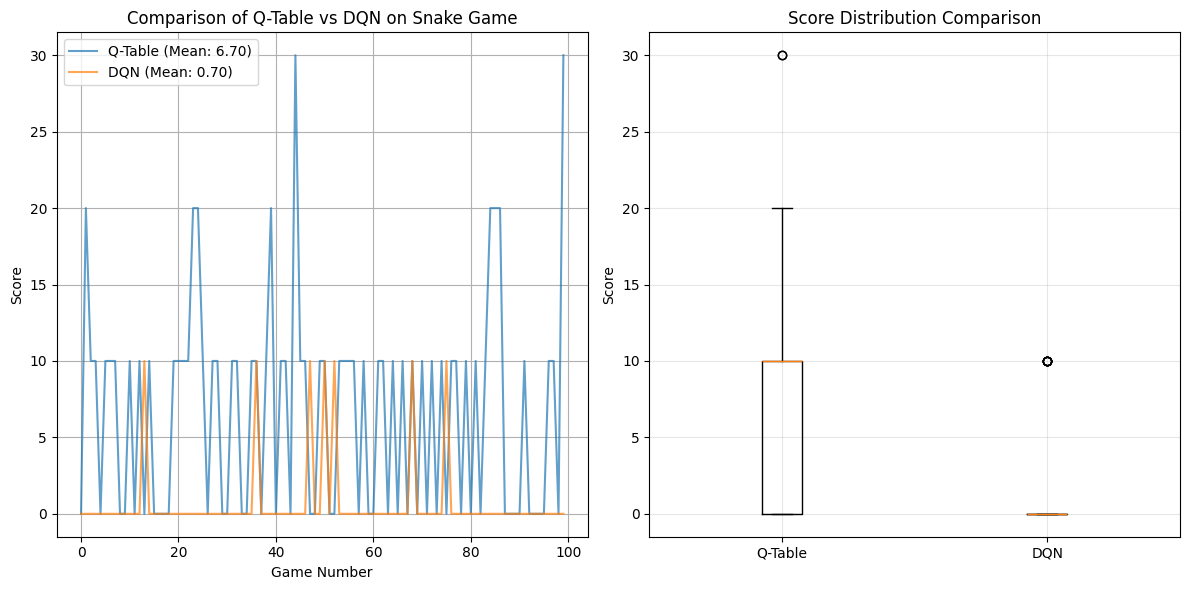

In [55]:
# Visualization
plt.figure(figsize=(12, 6))

plt.subplot(1, 2, 1)
plt.plot(q_scores, label=f'Q-Table (Mean: {np.mean(q_scores):.2f})', alpha=0.7)
plt.plot(dqn_scores, label=f'DQN (Mean: {np.mean(dqn_scores):.2f})', alpha=0.7)
plt.title('Comparison of Q-Table vs DQN on Snake Game')
plt.xlabel('Game Number')
plt.ylabel('Score')
plt.legend()
plt.grid(True)

plt.subplot(1, 2, 2)
plt.boxplot([q_scores, dqn_scores], labels=['Q-Table', 'DQN'])
plt.title('Score Distribution Comparison')
plt.ylabel('Score')
plt.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()